In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [41]:
df=pd.read_csv("imdb_raw.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         1000 non-null   str    
 1   director      1000 non-null   str    
 2   release_year  1000 non-null   str    
 3   runtime       1000 non-null   str    
 4   genre         1000 non-null   str    
 5   rating        1000 non-null   float64
 6   metascore     1000 non-null   int64  
 7   gross         1000 non-null   str    
dtypes: float64(1), int64(1), str(6)
memory usage: 62.6 KB


for merging purpose

In [42]:
budget_data = pd.DataFrame({
    'title': df['title'].unique(),
    'budget': np.random.randint(5, 200, size=len(df['title'].unique()))
})

cleaning data :- release year had bracket removed it and type conversion done to int

In [43]:
df['release_year'] = df['release_year'].str.extract(r'(\d{4})').astype(int)

remove min for analysis

In [44]:
df['runtime']=df['runtime'].str.replace(' min','').astype(int)

Remove signs and characters and zero value handling

In [45]:
df['gross']=df['gross'].str.replace('$','').str.replace('M','')
df['gross']=pd.to_numeric(df['gross'])

In [46]:
df['gross']=df['gross'].replace(0,np.nan)

simplyfing genre


In [47]:
df['genre']=df['genre'].str.split(',').str[0]

cleaning is done

NOW MERGE

In [48]:
df_final = pd.merge(df, budget_data, on='title', how='left')

filling missing values with median for budget if any

In [49]:
df_final['budget']=df_final['budget'].fillna(df_final['budget']).median()

Feature engineering

In [63]:
df_final['Profit_Millions']=df['gross']-df_final['budget']

In [51]:
df_final['ROI']=df_final['Profit_Millions']/df_final['budget']
df_final

,title,director,release_year,runtime,genre,rating,metascore,gross,budget,Profit_Millions,ROI
0,The Shawshank Redemption,Frank Darabont,1994,142,Drama,9.3,82,28.34,102.5,-74.16,-0.723512
1,The Godfather,Francis Ford Coppola,1972,175,Crime,9.2,100,134.97,102.5,32.47,0.316780
2,The Dark Knight,Christopher Nolan,2008,152,Action,9.0,84,534.86,102.5,432.36,4.218146
3,Schindler's List,Steven Spielberg,1993,195,Biography,9.0,95,96.90,102.5,-5.60,-0.054634
4,12 Angry Men,Sidney Lumet,1957,96,Crime,9.0,97,4.36,102.5,-98.14,-0.957463
...,...,...,...,...,...,...,...,...,...,...,...
995,A Very Long Engagement,Jean-Pierre Jeunet,2004,133,Drama,7.6,76,6.17,102.5,-96.33,-0.939805
996,Shine,Scott Hicks,1996,105,Biography,7.6,87,35.81,102.5,-66.69,-0.650634
997,Philomena,Stephen Frears,2013,98,Biography,7.6,77,37.71,102.5,-64.79,-0.632098
998,The Invisible Man,James Whale,1933,71,Horror,7.6,87,NaN,102.5,NaN,NaN


grouping to read insight together on basis of genre

In [64]:
genre_based_analysis = df_final.groupby('genre')[['Profit_Millions','ROI','rating']].mean().sort_values(by=['rating'],ascending=False)

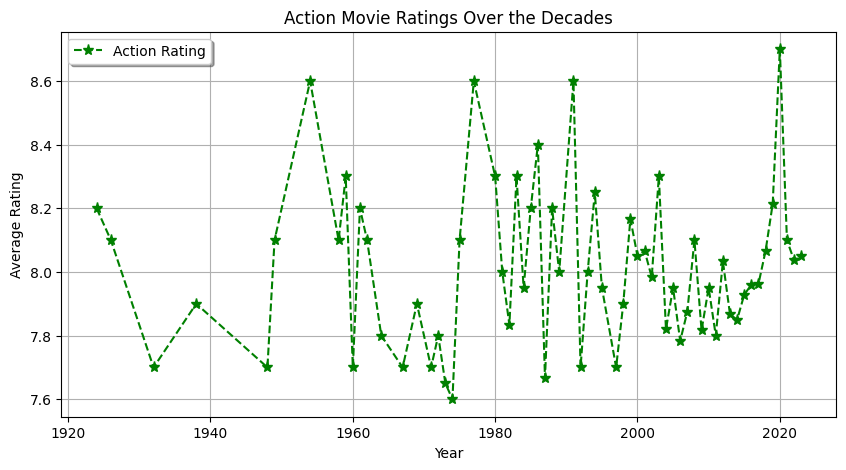

In [65]:
# Prepare data
action_movies = df_final[df_final['genre'] == 'Action'].groupby('release_year')['rating'].mean()

plt.figure(figsize=(10, 5))

# Using Formatting & Styling (Format Strings)
plt.plot(action_movies.index, action_movies.values, "g--*", markersize=8, label="Action Rating")

plt.xlabel("Year")
plt.ylabel("Average Rating")
plt.title("Action Movie Ratings Over the Decades")
plt.legend(loc="best", shadow=True)
plt.grid(True)
plt.show()